### Ideas
- see the grayscale value of the image 
- regression model based on grayscale on the image

#### Explore xml file

In [1]:
import xml.etree.ElementTree as ET
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
tree = ET.parse("annotations.xml")
root = tree.getroot()

for child in root:
    print(child.tag, child.attrib)

version {}
meta {}
track {'id': '0', 'label': 'planktonic', 'source': 'manual', 'group_id': '25'}
track {'id': '1', 'label': 'planktonic', 'source': 'manual', 'group_id': '24'}
track {'id': '2', 'label': 'planktonic', 'source': 'manual', 'group_id': '24'}
track {'id': '3', 'label': 'planktonic', 'source': 'manual'}
track {'id': '4', 'label': 'planktonic', 'source': 'manual'}
track {'id': '5', 'label': 'planktonic', 'source': 'manual', 'group_id': '26'}
track {'id': '6', 'label': 'planktonic', 'source': 'manual', 'group_id': '26'}
track {'id': '7', 'label': 'planktonic', 'source': 'manual', 'group_id': '28'}
track {'id': '8', 'label': 'planktonic', 'source': 'manual', 'group_id': '28'}
track {'id': '9', 'label': 'planktonic', 'source': 'manual', 'group_id': '28'}
track {'id': '10', 'label': 'planktonic', 'source': 'manual', 'group_id': '28'}
track {'id': '11', 'label': 'planktonic', 'source': 'manual', 'group_id': '28'}
track {'id': '12', 'label': 'planktonic', 'source': 'manual', 'grou

In [3]:
# From the annotations.xml, start = 0, stop = 40
# For every frame, how many different types of cells respectively
tree = ET.parse("annotations.xml")
root = tree.getroot()

meta = root.find("meta/task")
start_frame = int(meta.find("start_frame").text)
stop_frame  = int(meta.find("stop_frame").text)

frame_counts = {f: {} for f in range(start_frame, stop_frame+1)}

for track in root.findall("track"):
    label = track.attrib["label"]
    for shape in track:
        if shape.attrib.get("outside") == "0":
            f = int(shape.attrib["frame"])
            if label not in frame_counts[f]:
                frame_counts[f][label] = 0
            frame_counts[f][label] += 1

        
print(frame_counts)


{0: {'planktonic': 22}, 1: {'planktonic': 22, 'hyphae': 6}, 2: {'planktonic': 27, 'hyphae': 9}, 3: {'planktonic': 25, 'hyphae': 12}, 4: {'planktonic': 25, 'hyphae': 13}, 5: {'planktonic': 28, 'hyphae': 18}, 6: {'planktonic': 22, 'hyphae': 24}, 7: {'planktonic': 18, 'hyphae': 28}, 8: {'planktonic': 10, 'hyphae': 30, 'biofilm': 2}, 9: {'planktonic': 12, 'hyphae': 42, 'biofilm': 2}, 10: {'hyphae': 31, 'planktonic': 7, 'biofilm': 2}, 11: {'planktonic': 5, 'hyphae': 27, 'biofilm': 3}, 12: {'planktonic': 8, 'hyphae': 25, 'biofilm': 3}, 13: {'planktonic': 8, 'hyphae': 23, 'biofilm': 2}, 14: {'planktonic': 8, 'hyphae': 17, 'biofilm': 2}, 15: {'planktonic': 3, 'single dispersed cell': 1, 'hyphae': 17, 'biofilm': 2}, 16: {'single dispersed cell': 11, 'planktonic': 3, 'hyphae': 13, 'biofilm': 3}, 17: {'hyphae': 6, 'planktonic': 3, 'single dispersed cell': 23, 'biofilm': 3}, 18: {'single dispersed cell': 53, 'biofilm': 3, 'planktonic': 4, 'hyphae': 4}, 19: {'single dispersed cell': 81, 'planktonic

In [4]:
rows = []
for f, counts in frame_counts.items():
    row = {"frame": f, "n_total": sum(counts.values())}
    for label, num in counts.items():
        row[f"n_{label.replace(' ', '_')}"] = num
    rows.append(row)
df = pd.DataFrame(rows).fillna(0).sort_values("frame")
print(df)


    frame  n_total  n_planktonic  n_hyphae  n_biofilm  n_single_dispersed_cell
0       0       22          22.0       0.0        0.0                      0.0
1       1       28          22.0       6.0        0.0                      0.0
2       2       36          27.0       9.0        0.0                      0.0
3       3       37          25.0      12.0        0.0                      0.0
4       4       38          25.0      13.0        0.0                      0.0
5       5       46          28.0      18.0        0.0                      0.0
6       6       46          22.0      24.0        0.0                      0.0
7       7       46          18.0      28.0        0.0                      0.0
8       8       42          10.0      30.0        2.0                      0.0
9       9       56          12.0      42.0        2.0                      0.0
10     10       40           7.0      31.0        2.0                      0.0
11     11       35           5.0      27.0        3.

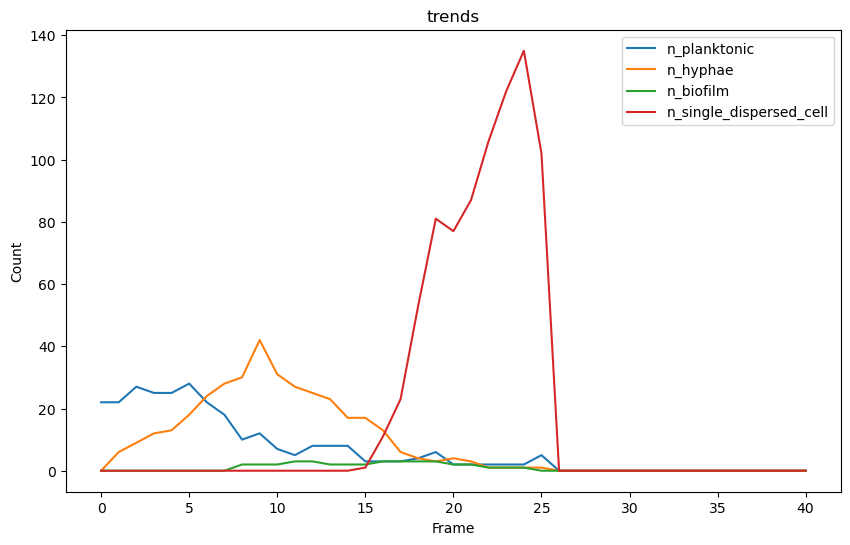

In [5]:
# visualize
label_cols = [c for c in df.columns if c not in ("frame", "n_total")]

plt.figure(figsize=(10,6))
for col in label_cols:
    plt.plot(df["frame"], df[col], label=col)

plt.xlabel("Frame")
plt.ylabel("Count")
plt.legend()
plt.title("trends")
plt.show()


#### Explore nd2 file

- We can use Fiji to transform nd2 file to tiff file. (or other files. There are lots of options)

In [6]:
file_path = "cellular-state-image-analysis/240922_mattLines.nd2"



(41, 1040, 1392) uint16


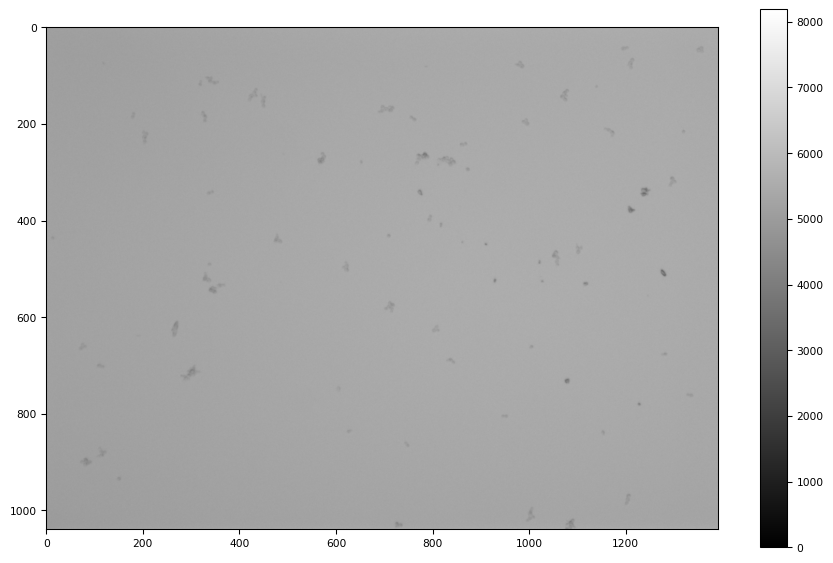

In [10]:
import tifffile as tiff

arr = tiff.imread("training.tif")
print(arr.shape, arr.dtype)

tiff.imshow(arr[0], cmap="gray")
plt.show()